In [3]:
import os
import numpy as np
import xarray as xr
import cftime
import pandas as pd 
import datetime
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm
import colorcet as cc
import cmocean

In [4]:
class HovmollerPlotter:
    def __init__(
            self, 
            data_dir, 
            output_dir, 
            fig_dir, 
            region_dict, 
            model_dict, 
            fig_name=None, 
            base_var="PRECT", 
            exps=None
        ):
        self.data_dir = data_dir
        self.output_dir = output_dir
        self.fig_dir = fig_dir
        self.fig_name= fig_name
        self.region_dict = region_dict
        self.model_dict = model_dict
        self.base_var = base_var
        self.exps = exps if exps is not None else list(model_dict.keys())
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.fig_dir, exist_ok=True)

    def _prepare_region_data(self, ds, region_key):
        region = self.region_dict[region_key]['region']
        lat_min, lat_max, lon_min, lon_max = region
    
        # Convert lon_min/max to 0–360 if negative
        lon_min = lon_min % 360
        lon_max = lon_max % 360
    
        lon_vals = ds['lon'].values
    
        # Handle dateline wraparound if needed
        if lon_min <= lon_max:
            ds = ds.sel(lon=ds.lon.where((ds.lon >= lon_min) & (ds.lon <= lon_max), drop=True))
        else:
            ds = ds.sel(lon=ds.lon.where((ds.lon >= lon_min) | (ds.lon <= lon_max), drop=True))
    
        # Sort longitude in ascending order
        ds = ds.sortby('lon')
    
        return ds
    
    def _load_dataset(self, model_key, region_key, fname_pattern):
        filename = fname_pattern.format(model_key, region_key)
        filepath = os.path.join(self.data_dir, filename)
        if not os.path.exists(filepath):
            print(f"[Missing] {filepath}")
            return None
    
        try:
            ds = xr.open_dataset(filepath)
            # Rename for consistency
            if 'longitude' in ds.coords and 'lon' not in ds.coords:
                ds = ds.rename({'longitude': 'lon'})
            print(f"[INFO] Loaded: {filepath}")
            print(f"         Lon Range: {ds['lon'].min().values} to {ds['lon'].max().values}")
            return ds
    
        except Exception as e:
            print(f"[Error] Could not open {filepath}: {e}")
            return None
        
    def _get_variable(self, ds, model_key):
        varname = f"{self.base_var}_{model_key}"
        if varname not in ds.variables:
            raise ValueError(f"Variable '{varname}' not found in dataset.")
        return ds[varname]

    def _format_lon_labels(self, lons):
        lons = np.asarray(lons)  # <-- Ensure it's an array before arithmetic
        labels = []
        lons = (((lons + 180) % 360) - 180).astype(float)
    
        for lon in lons:
            lon_int = int(np.round(lon))
            if lon_int == 0:
                labels.append("0")
            elif lon_int > 0:
                labels.append(f"{lon_int}E")
            else:
                labels.append(f"{abs(lon_int)}W")
        return labels

    def _compute_stats(self, data, ref):
        d1 = data.values.flatten()
        d2 = ref.values.flatten()
        mask = ~np.isnan(d1) & ~np.isnan(d2)
        d1, d2 = d1[mask], d2[mask]
        if len(d1) < 2:
            return np.nan, np.nan
        d1_anom, d2_anom = d1 - d1.mean(), d2 - d2.mean()
        pcorr = np.corrcoef(d1_anom, d2_anom)[0, 1]
        rmse = np.sqrt(np.mean((d1 - d2) ** 2))
        return pcorr, rmse

    def _save_data(self, data, lon, time, region_key, model_key):
        da = xr.DataArray(
            data,
            coords={"time": time, "lon": lon},
            dims=["time", "lon"],
            name=f"{self.base_var}_hov"
        )
        ds_out = xr.Dataset({da.name: da})
        out_file = os.path.join(self.output_dir, f"{model_key}_{region_key}_hovmoller.nc")
        ds_out.to_netcdf(out_file)
        print(f"[Saved Data]   {out_file}")

    def plot_all(
        self, 
        vmin=None, 
        vmax=None, 
        cmap="YlGnBu", 
        fontz=10,
        reverse_x = False,
        reverse_y = False
    ):
        for region_key, region_label in self.region_dict.items():
            fig, axs = plt.subplots(
                nrows=1,
                ncols=len(self.exps),
                figsize=(4 * len(self.exps), 8),
                sharey=True,
                constrained_layout=True
            )
            if len(self.exps) == 1:
                axs = [axs]

            # Prepare levels and colormap
            region_info = self.region_dict[region_key]
            region_label = region_info['label']
            level_values = np.asarray(region_info['levels'])
            
            # Number of bins
            N = len(level_values) - 1

            # === Use continuous colormap and extract N+2 values (extra for under/over) ===
            if isinstance(cmap, str):
                base_cmap = plt.get_cmap(cmap)
            else:
                base_cmap = cmap  # assumed to be a colormap object already
            
            # Sample N+2 evenly spaced colors from the base colormap
            color_vals = base_cmap(np.linspace(0, 1, N + 2))
            
            # Define extended color segments
            under_color = color_vals[0]
            main_colors = color_vals[1:-1]
            over_color = color_vals[-1]
            
            # Build final discrete colormap
            cmap_obj = ListedColormap(main_colors)
            cmap_obj.set_under(under_color)
            cmap_obj.set_over(over_color)
            
            # Define the norm using the bin boundaries (length N+1, matching main_colors length N)
            norm = mcolors.BoundaryNorm(boundaries=level_values, ncolors=N)
            
            im = None
            yticks, yticklabels = None, None

            for idx, model_key in enumerate(self.exps):
                if model_key not in self.model_dict:
                    continue
                model_label, short_key, fname_pattern = self.model_dict[model_key]
                ds = self._load_dataset(model_key, region_key, fname_pattern)
                if ds is None:
                    axs[idx].set_title(f"{model_label}\n(Missing)", fontsize=fontz)
                    axs[idx].axis("off")
                    continue

                try:
                    var_data = self._get_variable(ds, model_key)
                    time_dim = [d for d in ds.dims if "time" in d][0]
                    lon_dim = [d for d in ds.dims if "lon" in d or "longitude" in d][0]

                    data_zonal = var_data.mean(dim="lat") if "lat" in var_data.dims and var_data.dims["lat"] > 1 else var_data.squeeze()
                    vmin = np.nanmin(data_zonal)
                    vmax = np.nanmax(data_zonal)

                    time_values = ds[time_dim].values
                    time_labels = np.arange(len(time_values))
                    if yticks is None:
                        yticks = np.linspace(0, len(time_values) - 1, 10).astype(int)
                        yticklabels = [str(time_values[i])[:10] for i in yticks]

                    lon_vals = ds[lon_dim].values
                    if 'xticks' in region_info and region_info['xticks'] is not None:
                        tick_lons = np.asarray(region_info['xticks'])
                        
                        # If data longitudes are in 0–360, convert tick_lons accordingly
                        if lon_vals.min() >= 0 and lon_vals.max() > 180:
                            tick_lons = (tick_lons + 360) % 360
                    else:
                        tick_lons = np.linspace(lon_vals.min() + 10, lon_vals.max() - 10, 4)
                        
                    im = axs[idx].contourf(
                        ds[lon_dim], time_labels, data_zonal,
                        levels=level_values, 
                        cmap=cmap_obj, 
                        norm=norm,
                        extend="both"
                    )
                    
                    panel_label = f"({chr(97 + idx)}) {model_label}" # chr(97) = 'a', so this gives (a), (b), ...
                    axs[idx].set_title(panel_label, fontsize=fontz, loc="left")
                    #axs[idx].set_title(region_label, fontsize=fontz, loc="right")
                    axs[idx].set_xticks(tick_lons)
                    axs[idx].set_xticklabels(self._format_lon_labels(tick_lons), fontsize=fontz)
                    axs[idx].set_xlabel("Longitude", fontsize=fontz)
                    if reverse_x:
                        axs[idx].invert_xaxis()  # <-- Reverse the x-axis here
                        
                    if reverse_y:
                        axs[idx].invert_yaxis()  # <-- Reverse the x-axis here

                    if model_key != "TRMM" and "TRMM" in self.exps:
                        try:
                            ds_trmm = self._load_dataset("TRMM", region_key, self.model_dict["TRMM"][2])
                            ref_data = self._get_variable(ds_trmm, "TRMM")
                            ref_zonal = ref_data.mean(dim="lat") if "lat" in ref_data.dims and ref_data.dims["lat"] > 1 else ref_data.squeeze()
                            pcorr, rmse = self._compute_stats(data_zonal, ref_zonal)
                            axs[idx].text(0.98, 0.02,
                                          f"PCC={pcorr:.2f}\nRMSE={rmse:.2f}",
                                          transform=axs[idx].transAxes,
                                          fontsize=fontz, va="bottom", ha="right",
                                          bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))
                        except Exception as e:
                            print(f"[Warning] Metrics failed for {model_key} vs TRMM: {e}")

                    if idx == 0:
                        #axs[idx].set_ylabel("Time", fontsize=fontz)
                        axs[idx].set_yticks(yticks)
                        axs[idx].set_yticklabels(yticklabels, rotation=0, fontsize=fontz)

                    self._save_data(data_zonal, ds[lon_dim], ds[time_dim], region_key, model_key)

                except Exception as e:
                    axs[idx].text(0.5, 0.5, f"Error: {e}", ha='center')
                    axs[idx].axis("off")
                    print(f"[Error] {model_key} - {region_key}: {e}")

            cbar = fig.colorbar(
                im,
                ax=axs,
                orientation="horizontal",
                ticks=level_values,
                spacing="uniform",
                pad=0.06,        # space between plot and colorbar
                shrink=0.75,      # controls length
                aspect=60        # higher = thinner
            )
            
            cbar.set_label(f"{self.base_var} (mm/day)", fontsize=fontz)
            cbar.ax.tick_params(labelsize=fontz)  # <-- this sets fontsize for tick labels
            if self.fig_name is not None:
                out_file = os.path.join(self.fig_dir, self.fig_name)
            else:
                out_file = os.path.join(self.fig_dir, f"Hovmoller_{region_key}.pdf")
            fig.savefig(out_file, dpi=600)
            plt.show()
            plt.close(fig)
            print(f"[Saved Figure] {out_file}")


[INFO] Loaded: /home/x-szhang3/nudging_analysis/nudging_evaluation/Nudge_Strategy/Hovmoller/data/PRECT_TRMM_Tropics.nc
         Lon Range: 60.5 to 269.5
[Saved Data]   /home/x-szhang3/nudging_analysis/nudging_evaluation/data/error_metrics/TRMM_Tropics_hovmoller.nc
[INFO] Loaded: /home/x-szhang3/nudging_analysis/nudging_evaluation/Nudge_Strategy/Hovmoller/data/PRECT_CLIM_Tropics.nc
         Lon Range: 60.5 to 269.5
[INFO] Loaded: /home/x-szhang3/nudging_analysis/nudging_evaluation/Nudge_Strategy/Hovmoller/data/PRECT_TRMM_Tropics.nc
         Lon Range: 60.5 to 269.5
[Saved Data]   /home/x-szhang3/nudging_analysis/nudging_evaluation/data/error_metrics/CLIM_Tropics_hovmoller.nc
[INFO] Loaded: /home/x-szhang3/nudging_analysis/nudging_evaluation/Nudge_Strategy/Hovmoller/data/PRECT_NDGUV_Tropics.nc
         Lon Range: 60.5 to 269.5
[INFO] Loaded: /home/x-szhang3/nudging_analysis/nudging_evaluation/Nudge_Strategy/Hovmoller/data/PRECT_TRMM_Tropics.nc
         Lon Range: 60.5 to 269.5
[Saved Dat

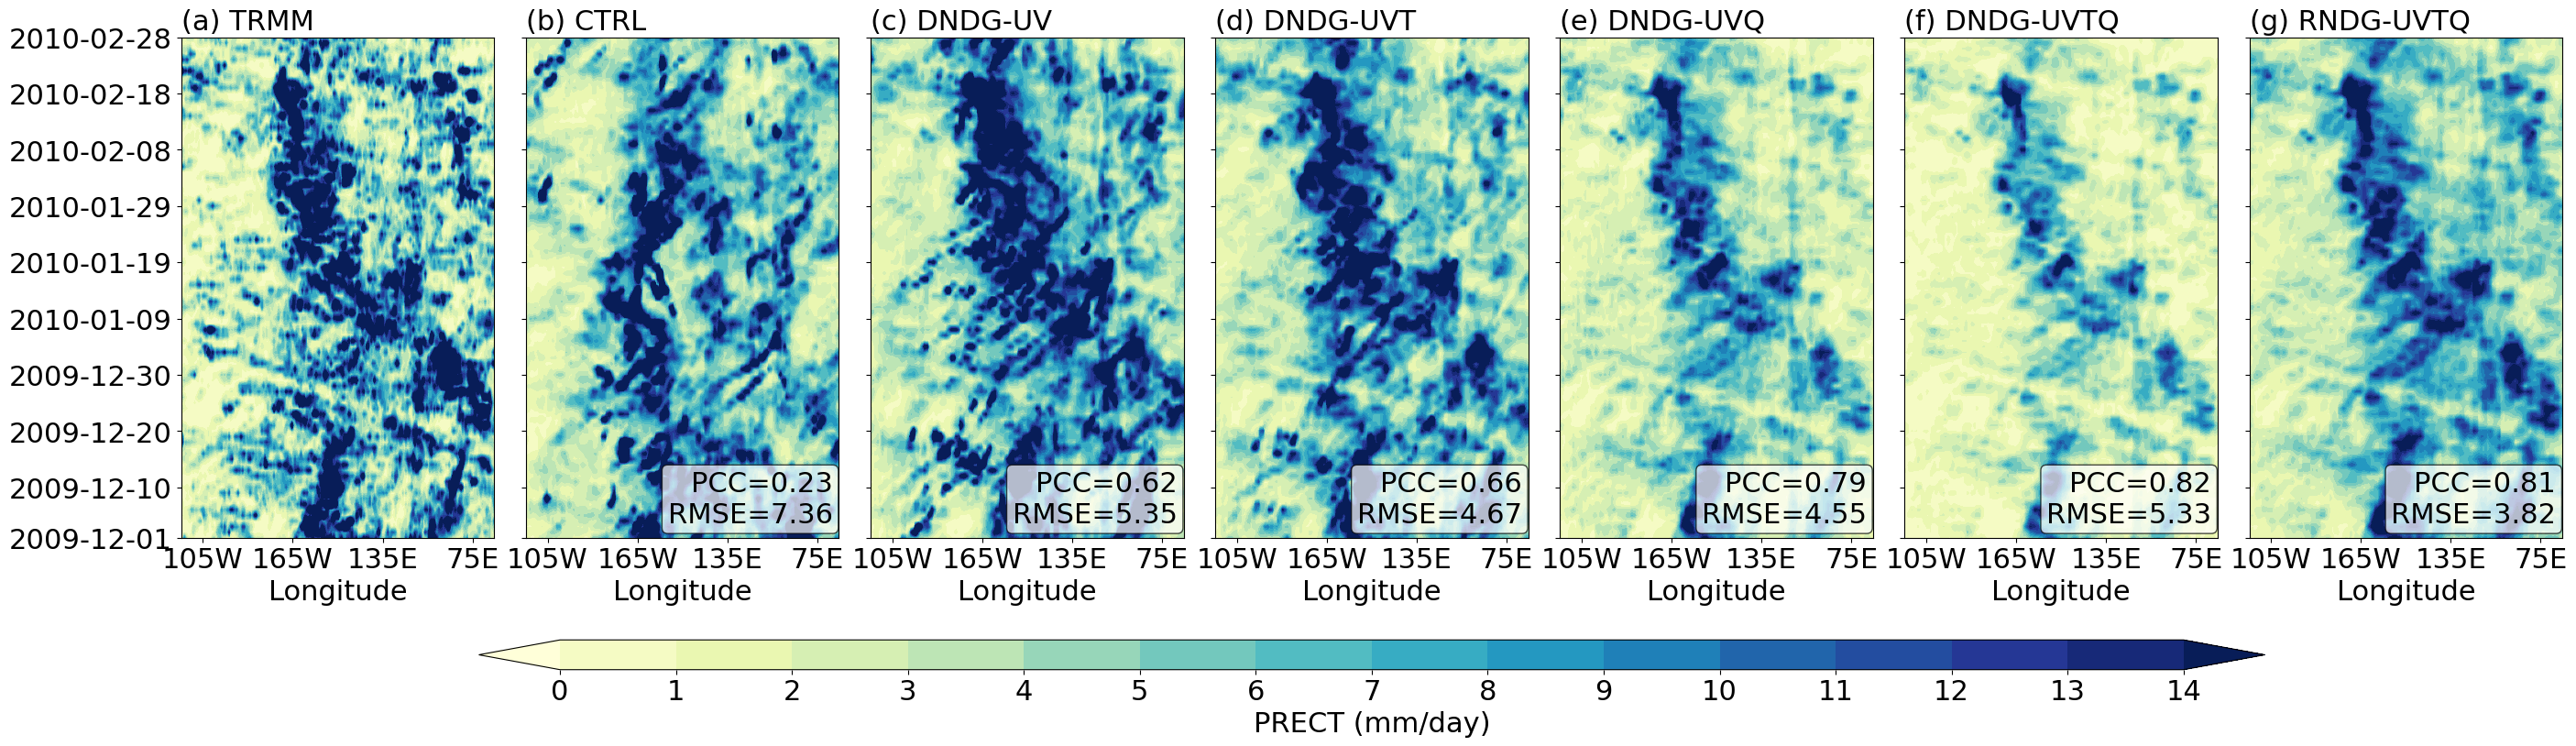

[Saved Figure] ./Figure_01.pdf


In [5]:
if __name__ == "__main__":
    top_path = "/home/x-szhang3/nudging_analysis/nudging_evaluation"
    data_path = f"{top_path}/Nudge_Strategy/Hovmoller/data"
    out_path = f"{top_path}/data/nudge_strategy/hovmoller"
    out_path  = "/home/x-szhang3/nudging_analysis/nudging_evaluation/data/error_metrics"

    fig_path = "./"
    fig_name = "Figure_01.pdf"
    
    region_dict = {
        'Tropics': {
            'label': "Tropics",
            'region': (-10, 10, -90, 60),
            'levels': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
            'xticks': [75, 135, 195, 255]
        },
#        'CONUS': {
#            'label': "Mid-Lat",
#            'region': (25, 50, -60, 150),
#            'levels': [0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
#            'xticks': None
#        },
#        'North_Pacific': {
#            'label': "North Pacific",
#            'region': (10, 65, -80, 110),
#            'levels': [0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
#            'xticks': [165, 210, 255, 300]
#        },
    }

    model_dict = {
        'TRMM':             ('TRMM',          'obs',          "PRECT_{}_{}.nc"),
        'CLIM':             ('CTRL',          'clim',         "PRECT_{}_{}.nc"),
        'NDGUV':            ('DNDG-UV',       'ndguv',        "PRECT_{}_{}.nc"),
        'NDGUVT':           ('DNDG-UVT',      'ndguvt',       "PRECT_{}_{}.nc"),
        'NDGUVQ':           ('DNDG-UVQ',      'ndguvq',       "PRECT_{}_{}.nc"),
        'NDGUVTQ':          ('DNDG-UVTQ',     'ndguvtq',      "PRECT_{}_{}.nc"),
        'UVTQ3_NPBL_NUPP':  ('RNDG-UVTQ',     'ndguvtq',      "PRECT_{}_{}.nc"),
    }

    exps = ['TRMM', 'CLIM', 'NDGUV', 'NDGUVT', 'NDGUVQ', 'NDGUVTQ', 'UVTQ3_NPBL_NUPP']
    # === Colormap and Color Levels ===
    base_cmap = "YlGnBu" #"YlGnBu" #cc.cm["CET_R1"] #"YlGnBu"
    base_cmap = cc.cm["CET_R1"] 
    base_cmap = cmocean.cm.thermal #deep #rain
    base_cmap = cc.cm["CET_D2"] 
    #base_cmap = cc.cm["CET_C9"]
    base_cmap = "YlGnBu" #"YlGnBu" #cc.cm["CET_R1"] #"YlGnBu"
    base_var = "PRECT"
    base_font = 22
    
    plotter = HovmollerPlotter(
        data_dir=data_path,
        output_dir=out_path,
        fig_dir=fig_path,
        fig_name=fig_name,
        region_dict=region_dict,
        model_dict=model_dict,
        base_var=base_var,
        exps=exps
    )

    plotter.plot_all(
        cmap=base_cmap, 
        fontz=base_font, 
        reverse_x=True,
        reverse_y=False
    )
